# Problem Statement: Predicting Car Prices using Linear Regression

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
horsepower = np.array([120, 100, 200, 180, 250, 300])
car_price = np.array([8, 6, 14, 12, 18, 25]) #in lakhs of rupees
print(np.size(horsepower))
print(np.size(car_price))

6
6


In [25]:
weight = 6.5 # weight and bias are manually set
bias = 1

In [5]:
print(horsepower * car_price)

[ 960  600 2800 2160 4500 7500]


Text(0.5, 0, 'Horspower of Cars (in hp)')

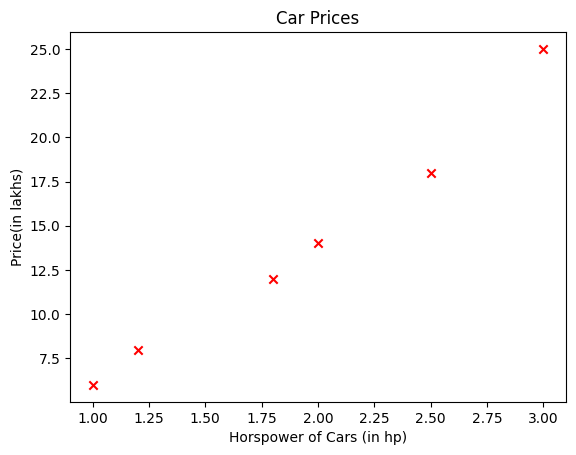

In [19]:
plt.scatter(horsepower, car_price, marker='x', c='r')
plt.title("Car Prices")
plt.ylabel("Price(in lakhs)")
plt.xlabel("Horspower of Cars (in hp)")

In [16]:
def compute_model_output(x, w, b):
  m = x.shape[0]
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = w * x[i] + b
  return f_wb

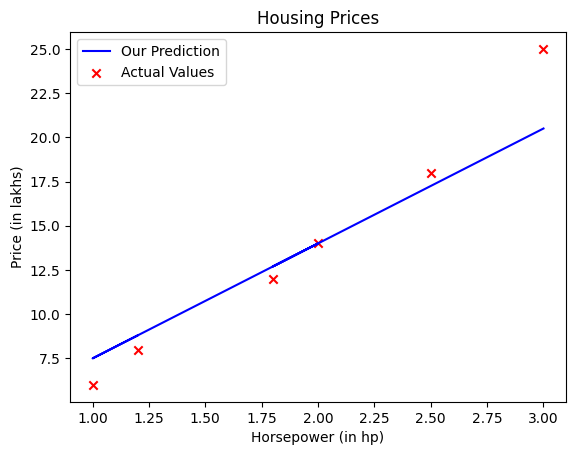

In [26]:
tmp_f_wb = compute_model_output(horsepower, weight, bias)

plt.plot(horsepower, tmp_f_wb, c='b', label='Our Prediction')
plt.scatter(horsepower, car_price, marker='x', c='r', label='Actual Values')
plt.title("Housing Prices")
plt.ylabel("Price (in lakhs)")
plt.xlabel("Horsepower (in hp)")
plt.legend()
plt.show()

In [6]:
def cost_function(horsepower, car_price):
  cost = 0
  no_of_examples = horsepower.size
  for i in range(no_of_examples):
      y_hat = horsepower[i] * weight + bias
      cost += (y_hat - car_price[i]) ** 2

  cost = (1 / (2 * no_of_examples)) * cost
  return cost

In [7]:
mean_squared_error = cost_function(horsepower, car_price)
print(mean_squared_error)

6.854166666666666


In [29]:
def compute_gradient(horsepower, car_price, weight, bias):
  dj_dw = 0
  dj_db = 0
  alpha = 0.05
  m = horsepower.shape[0]

  for i in range(m):
    f_wb = weight * horsepower[i] + bias
    dj_dw_i = (f_wb - car_price[i]) * horsepower[i]
    dj_db_i = (f_wb - car_price[i])
    dj_db += dj_db_i
    dj_dw += dj_dw_i

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [37]:
import math
def gradient_descent(horsepower, car_price, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
  J_history = []
  p_history = []
  b = b_in
  w = w_in

  for i in range(num_iters):
    dj_dw , dj_db = gradient_function(horsepower, car_price, w, b)

    b = b - alpha * dj_db
    w = w - alpha * dj_dw

    if i < 100000:
      J_history.append(cost_function(horsepower, car_price, w, b))
      p_history.append([w, b])

    if i % math.ceil(num_iters/10) == 0:
      print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",f"w: {w: 0.3e}, b:{b: 0.5e}")

  return w, b, J_history, p_history

In [38]:
w_final, b_final, J_hist, p_hist = gradient_descent(horsepower, car_price, 0, 0, 1.0e2, 10000, cost_function, compute_gradient)

Iteration    0: Cost 2.88e+07  dj_dw: -3.087e+01, dj_db: -1.383e+01   w:  3.087e+03, b: 1.38333e+03
Iteration 1000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan
Iteration 2000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan
Iteration 3000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan
Iteration 4000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan
Iteration 5000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan
Iteration 6000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan
Iteration 7000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan


/tmp/ipython-input-4113994329.py:25: RuntimeWarning: overflow encountered in square
  return (1/(2*m)) * np.sum((y_hat - y) ** 2)
/tmp/ipython-input-3402816059.py:12: RuntimeWarning: overflow encountered in scalar multiply
  w = w - alpha * dj_dw
/tmp/ipython-input-3402816059.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - alpha * dj_dw


Iteration 8000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan
Iteration 9000: Cost nan  dj_dw:  nan, dj_db:  nan   w:  nan, b: nan


## To actually learn the best fit line, you need gradient descent to update them automatically.

Epoch 0: Cost=100.6127, w=0.4026, b=0.2354
Epoch 100: Cost=2.3555, w=6.2690, b=2.2957
Epoch 200: Cost=2.0123, w=6.5490, b=1.7830
Epoch 300: Cost=1.7312, w=6.7755, b=1.3037
Epoch 400: Cost=1.4987, w=6.9813, b=0.8678
Epoch 500: Cost=1.3066, w=7.1684, b=0.4714
Epoch 600: Cost=1.1477, w=7.3385, b=0.1111
Epoch 700: Cost=1.0164, w=7.4932, b=-0.2165
Epoch 800: Cost=0.9079, w=7.6339, b=-0.5144
Epoch 900: Cost=0.8182, w=7.7617, b=-0.7853


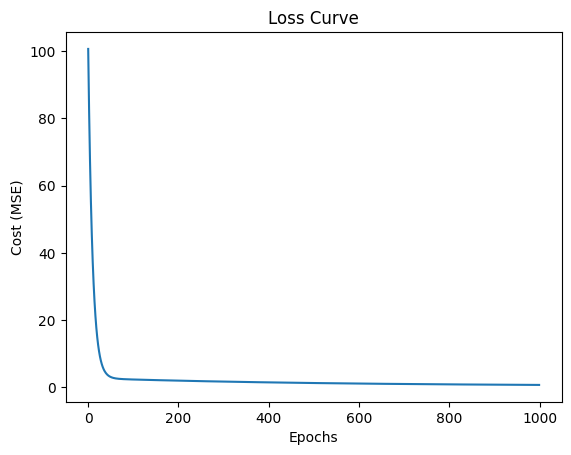

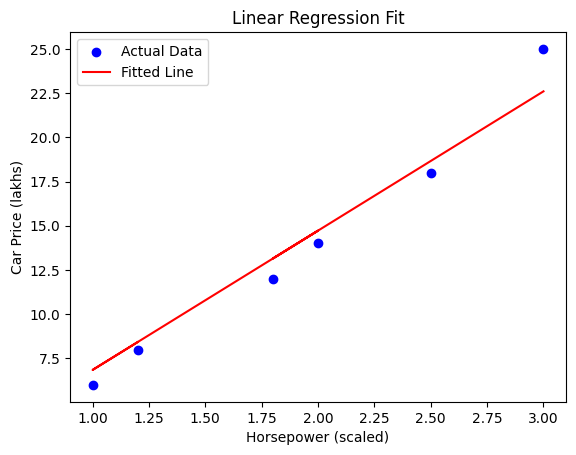

In [32]:
# ================================
# 1. Data
# ================================
horsepower = np.array([120, 100, 200, 180, 250, 300], dtype=np.float32)
car_price = np.array([8, 6, 14, 12, 18, 25], dtype=np.float32)

# Scale horsepower for better training
horsepower = horsepower / 100.0

# ================================
# 2. Initialize params
# ================================
w = 0.1
b = 0.1
lr = 0.01   # learning rate
epochs = 1000
losses = []

# ================================
# 3. Cost Function
# ================================
def cost_function(x, y, w, b):
    m = x.size
    y_hat = w * x + b
    return (1/(2*m)) * np.sum((y_hat - y) ** 2)

# ================================
# 4. Training Loop (Gradient Descent)
# ================================
for epoch in range(epochs):
    m = horsepower.size
    y_hat = w * horsepower + b

    # Gradients
    dw = (1/m) * np.sum((y_hat - car_price) * horsepower)
    db = (1/m) * np.sum(y_hat - car_price)

    # Update params
    w -= lr * dw
    b -= lr * db

    # Store loss
    cost = cost_function(horsepower, car_price, w, b)
    losses.append(cost)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Cost={cost:.4f}, w={w:.4f}, b={b:.4f}")

# ================================
# 5. Plot Loss Curve
# ================================
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Loss Curve")
plt.show()

# ================================
# 6. Final Line Fit Visualization
# ================================
plt.scatter(horsepower, car_price, color="blue", label="Actual Data")
plt.plot(horsepower, w * horsepower + b, color="red", label="Fitted Line")
plt.xlabel("Horsepower (scaled)")
plt.ylabel("Car Price (lakhs)")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()


# 📈 Mini Project 2: Predicting Student Scores from Study Hours

## Problem Statement

You are given a dataset of students’ study hours and their corresponding exam scores. The goal is to **predict the exam score** based on the number of hours studied using **linear regression from scratch**.

---

## Dataset (small & simple)

```python
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=np.float32)
exam_scores = np.array([35, 50, 65, 70, 75, 80, 85, 90], dtype=np.float32)
```

---

## Tasks

1. Implement the linear regression model:

   $$
   y = w \cdot x + b
   $$

   where $w$ is the slope (effect of study hours), $b$ is the bias (base score).

2. Define the **Mean Squared Error (MSE)** cost function.

3. Implement **gradient descent** to learn optimal $w$ and $b$.

4. Train the model and plot:

   * **Loss curve** (MSE vs epochs).
   * **Regression line vs actual data**.

---

## Extension Ideas

* Predict the exam score for **10 hours of study**.
* Add some **noise** (e.g., random distractions) and see how the model adapts.
* Compare your results with `sklearn.LinearRegression`.

---


Epoch 0: Cost=1399.8602, w=3.5450, b=0.7820
Epoch 1000: Cost=12.9214, w=8.0714, b=31.5203
Epoch 2000: Cost=10.8279, w=7.3717, b=35.4544
Epoch 3000: Cost=10.7894, w=7.2768, b=35.9878
Epoch 4000: Cost=10.7887, w=7.2639, b=36.0600
Epoch 5000: Cost=10.7887, w=7.2622, b=36.0698
Epoch 6000: Cost=10.7887, w=7.2621, b=36.0705
Epoch 7000: Cost=10.7887, w=7.2621, b=36.0705
Epoch 8000: Cost=10.7887, w=7.2621, b=36.0705
Epoch 9000: Cost=10.7887, w=7.2621, b=36.0705


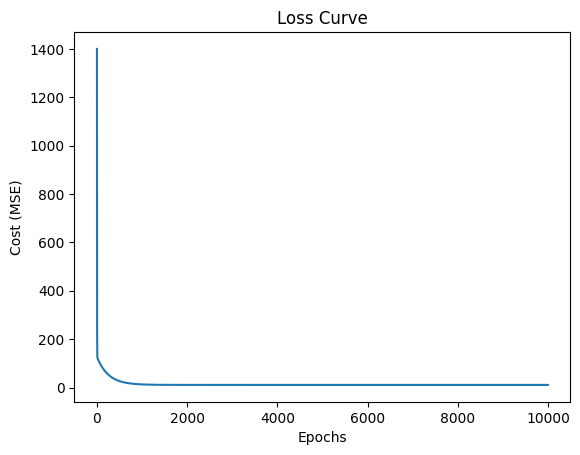

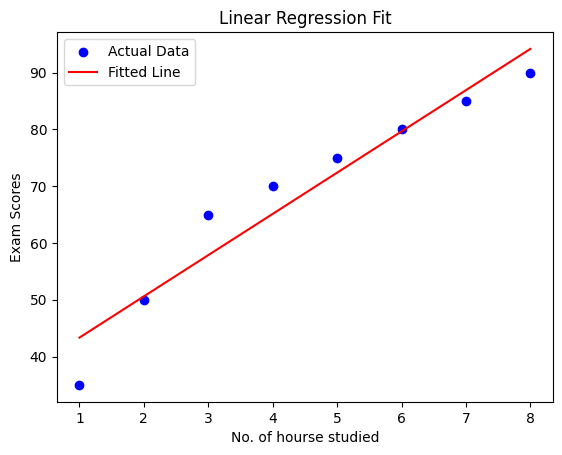

In [52]:
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=np.float32)
exam_scores = np.array([35, 50, 65, 70, 75, 80, 85, 90], dtype=np.float32)

# Initialise parameters
w = 0.1
b = 0.1
alpha = 0.01
epochs = 10000
losses = []

# Cost Function
def compute_cost(x, y, w, b):
  y_hat = w * x + b
  return (1 / (2 * np.size(x)) * np.sum((y_hat - y) ** 2))


# Gradient Descent

for epoch in range(epochs):
  m = study_hours.size
  y_hat = w * study_hours + b

  dw = (1/m) * np.sum((y_hat - exam_scores) * study_hours)
  db = (1/m) * np.sum(y_hat - exam_scores)

  w -= alpha * dw
  b -= alpha * db

  cost = compute_cost(study_hours, exam_scores, w, b)
  losses.append(cost)

  if epoch % 1000 == 0:
    print(f"Epoch {epoch}: Cost={cost:.4f}, w={w:.4f}, b={b:.4f}")


plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Loss Curve")
plt.show()

plt.scatter(study_hours, exam_scores, color='blue', label="Actual Data")
plt.plot(study_hours, w * study_hours + b, color="red", label="Fitted Line")
plt.xlabel("No. of hourse studied")
plt.ylabel("Exam Scores")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

In [54]:
print("Weight: ", w)
print("Bias: ", b)
print("Score of 10 hrs of study is: ", min(w * 10 + b, 100))


Weight:  7.2620716
Bias:  36.070488
Score of 10 hrs of study is:  100


In [55]:
from sklearn.linear_model import LinearRegression

Sklearn Coefficients:
Weight (slope): 7.2619033
Bias (intercept): 36.071434
Predicted score for 10 hours: 108.69046688079834


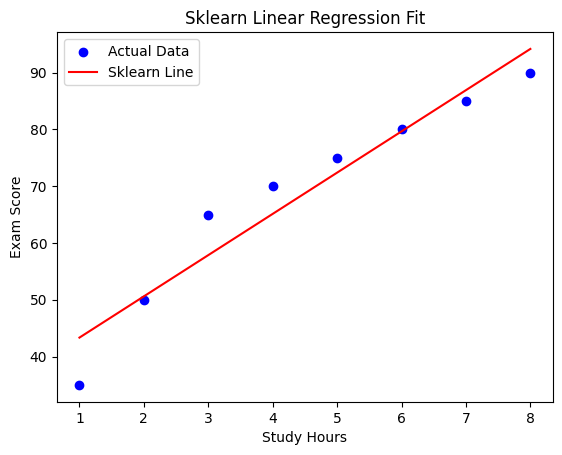

In [57]:

study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=np.float32).reshape(-1, 1)
exam_scores = np.array([35, 50, 65, 70, 75, 80, 85, 90], dtype=np.float32)

lin_reg = LinearRegression()
lin_reg.fit(study_hours, exam_scores)

print("Sklearn Coefficients:")
print("Weight (slope):", lin_reg.coef_[0])
print("Bias (intercept):", lin_reg.intercept_)

# Prediction for 10 hours
pred_10 = lin_reg.predict([[10]])
print("Predicted score for 10 hours:", pred_10[0])

# =========================
# Plot comparison
# =========================
plt.scatter(study_hours, exam_scores, color='blue', label="Actual Data")

# Sklearn line
plt.plot(study_hours, lin_reg.predict(study_hours), color='red', label="Sklearn Line")

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.legend()
plt.title("Sklearn Linear Regression Fit")
plt.show()


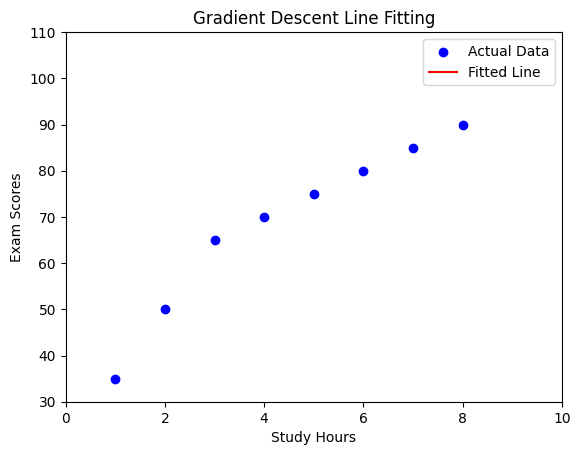

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================
# Dataset
# =========================
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=np.float32)
exam_scores = np.array([35, 50, 65, 70, 75, 80, 85, 90], dtype=np.float32)

# =========================
# Initialize params
# =========================
w = 0.1
b = 0.1
alpha = 0.01
epochs = 100

# Store params for animation
params_history = []

# Cost function
def compute_cost(x, y, w, b):
    y_hat = w * x + b
    return (1 / (2 * x.size)) * np.sum((y_hat - y) ** 2)

# Gradient Descent with history
for epoch in range(epochs):
    m = study_hours.size
    y_hat = w * study_hours + b

    dw = (1/m) * np.sum((y_hat - exam_scores) * study_hours)
    db = (1/m) * np.sum(y_hat - exam_scores)

    w -= alpha * dw
    b -= alpha * db

    params_history.append((w, b))

# =========================
# Animation
# =========================
fig, ax = plt.subplots()
ax.scatter(study_hours, exam_scores, color="blue", label="Actual Data")
line, = ax.plot([], [], "r-", label="Fitted Line")
ax.set_xlim(0, 10)
ax.set_ylim(30, 110)
ax.set_xlabel("Study Hours")
ax.set_ylabel("Exam Scores")
ax.set_title("Gradient Descent Line Fitting")
ax.legend()

def update(frame):
    w, b = params_history[frame]
    y_pred = w * study_hours + b
    line.set_data(study_hours, y_pred)
    return line,

ani = FuncAnimation(fig, update, frames=len(params_history), interval=200, blit=True)
plt.show()
ani.save("gradient_descent.gif", writer="pillow")
